## Introduction

Large Language Models (LLMs), such as GPT-2, learn statistical relationships between tokens in text. At each step, the model processes a sequence of tokens and assigns a probability to each possible next token. This probability distribution reflects the model's knowledge of which words and phrases naturally follow each other in a given context.

## Task

You have a pre-trained GPT-2 XL model and a text dataset containing verses from various plays by William Shakespeare.
Your task is to build the best possible model that, given a fragment of text (size 512 tokens), can predict which tokens from a list will appear later in the text (size `q_size = 128` subsequent tokens).

## Data

The dataset consists of three parts:
1. Training dataset, which is a coherent text fragment consisting of 301,966 tokens. The data comes from verses of various plays by William Shakespeare.

2. Validation dataset - 99 examples (built from a different fragment of the same text as the training set), each consisting of:
   - `prompt` — a sequence of 512 context tokens.
   - `good_tokens` - `q_size = 128` tokens that actually appear after the prompt in the original text.
   - `bad_tokens` — `q_size = 128` tokens that **do not** appear in the next `q_size` tokens after the prompt (negatives).
   - `token_list` - contains exactly 256 tokens, of which 128 are `good_tokens` and 128 are `bad_tokens`, in random order.

3. Test dataset - consists of 100 examples that will be used to evaluate your solution. You do not have access to the test data while solving the task.


## Evaluation Criterion
Your solution, having access to `prompt` and `token_list`, must distinguish `good_tokens` from `bad_tokens` and return `good_answer` and `bad_answer`, which are respectively the tokens predicted by the model as belonging to each group. Both lists should form a disjoint partition of `token_list`, i.e., each token from `token_list` must be assigned to exactly one of them.

The quality of your solution will be measured by **classification accuracy**:

$$
\text{score} = \frac{1}{2}*(\frac{|\text{set}(good\_tokens) \cap \text{set}(good\_answer)|}{|\text{set}(good\_tokens)|} + \frac{|\text{set}(bad\_tokens) \cap \text{set}(bad\_answer)|}{|\text{set}(bad\_tokens)|})
$$

You can score from 0 to 100 points for this task. The result will be scaled linearly depending on the achieved **average accuracy** on the entire test set:

- **Accuracy ≤ 0.62**: 0 points
- **Accuracy ≥ 0.68**: 100 points
- **Values in between**: scaled linearly.

The final score is calculated according to the formula:
$$
\text{Points} =
\begin{cases}
0 & \text{for } \text{Accuracy} \leq 0.62 \\
100 \times \frac{\text{Accuracy} - 0.62}{0.68 - 0.62} & \text{for } 0.62 < \text{Accuracy} < 0.68 \\
100 & \text{for } \text{Accuracy} \geq 0.68
\end{cases}
$$

## Constraints
* Your solution will be tested on the Competition Platform without internet access.
* Evaluation of your final solution cannot take longer than **5 minutes** (with GPU).
* Allowed libraries: `numpy`, `pytorch`.

## Submission Files
This notebook supplemented with your solution (see class `YourSolution`).

## Evaluation
Remember that during checking, the flag `FINAL_EVALUATION_MODE` will be set to `True`.

You can score between 0 and 100 points for this task. The number of points you earn will be calculated on the (secret) test set on the Competition Platform based on the above formula, rounded to an integer. If your solution does not meet the above criteria or does not run correctly, you will receive 0 points for the task.

# Starter Code
In this section, we initialize the environment by importing the necessary libraries and functions, and load the GPT-2 model. The prepared code will facilitate efficient data manipulation and building the proper solution.

In [1]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
FINAL_EVALUATION_MODE = False # During checking on the tester, the flag automatically changes to True.

In [2]:
# ######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
import os
import random

# Setting the random seed to ensure deterministic results
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device      = 'cuda' if torch.cuda.is_available() else 'cpu'
block_size  = 1024
prompt_size = 512
q_size      = 128   # must be equal to WINDOW_LEN in AuthorsSolution
assert prompt_size + 3 * q_size <= block_size

print(f"Used device: {device}")

Used device: cuda


## Model Definition
Below is the GPT-2 model used in the task. You can freely change this code - e.g., add new methods. For example, we created a `model.query(prompt, token_list)` method that returns logits based on the prompt - described below.

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=True)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=True)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head  = config.n_head
        self.n_embd  = config.n_embd
        self.dropout = config.dropout

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                dropout_p=self.dropout if self.training else 0, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp  = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        from types import SimpleNamespace
        config = SimpleNamespace(**config)
        config.dropout = 0.0
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        print("Number of model parameters: %.2fM" % (sum(p.numel() for p in self.parameters()) / 1e6,))

    def forward(self, idx):
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        return x @ self.transformer.wte.weight.mT

    def query(self, prompt, token_list):
        """
        For a given prompt and token list, returns a list of logits:

        Args:
            prompt     (torch.Tensor): 1D tensor of context tokens, shape [T].
            token_list (list[int]):    list of tokens to classify.

        Returns:
            (list[int]): list of logits for the given tokens.
        """
        ctx = torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16) if device == 'cuda' else torch.amp.autocast(device_type='cpu', enabled=False)
        with torch.no_grad():
            with ctx:
                L = len(token_list)
                logits = self(prompt[None, ...])[0, -1, :]
                logits = logits.to(torch.float32).cpu().detach().numpy()[token_list].tolist()
                return logits


## Loading Model and Data

The following cell loads the **pre-trained** GPT-2 XL model with standard weights and the text data. The data is already tokenized — **you do not need to install any tokenizer**.

Available files:
- `ckpt.pt`   — GPT-2 XL weights (standard OpenAI weights, without additional training),
- `train_data` — tokens of the training set (uint16, GPT-2 BPE encoding),
- `val_data`   — tuple `(prompt, good_tokens, bad_tokens, token_list)` used for evaluating the solution. You can assume that the test data will be in the same format as the validation data.

In [4]:
# ######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

weights_file = "ckpt.pt"
if not os.path.exists(weights_file):
    import gdown

    print("Downloading model...")
    url = "https://drive.google.com/file/d/1aGenswqFszSBWYlXN26fkwpdyluTxfUI/view?usp=drive_link"
    gdown.download(url, weights_file)

print("Loading pre-trained GPT-2 XL from ckpt.pt ...")
checkpoint = torch.load(weights_file, map_location=device, weights_only=False)
gptconf    = checkpoint['model_args']
model      = GPT(gptconf)
model.load_state_dict(checkpoint['model'])
model.to(device)
model.eval()
vocab_size = gptconf['vocab_size']
checkpoint = None
print("Model loaded successfully.")

train_data = torch.load("./data/train_data.pt", weights_only=False)
val_data   = torch.load("./data/val_data.pt", weights_only=False)

Loading pre-trained GPT-2 XL from ckpt.pt ...
Number of model parameters: 774.03M
Model loaded successfully.


## Data Inspection

In [5]:
if not FINAL_EVALUATION_MODE:
    from tokenizers import Tokenizer

    enc = Tokenizer.from_file("./tokenizer.json") # we use the tokenizer for data inspection - the data is already tokenized - you do not need to modify or use the tokenizer
    print("First 10 training tokens:", train_data[:10])
    print("First 10 training tokens as text:", enc.decode(train_data[:10]))

    for prompt, good_tokens, bad_tokens, token_list in val_data:
        print("First example from validation set")
        print("Prompt (first 10 tokens):", prompt.tolist()[:10])
        print("Prompt (first 10 tokens) as text:", enc.decode(prompt.tolist()))
        print("Good tokens (first 10):", good_tokens[:10])
        print("Good tokens (first 10) as text:", [enc.decode([x]) for x in good_tokens])
        print("Bad tokens (first 10):", bad_tokens[:10])
        print("Bad tokens (first 10) as text:", [enc.decode([x]) for x in bad_tokens])
        print("All tokens (bad and good) (first 10):", token_list[:10])
        print("All tokens (bad and good) (first 10) as text:", [enc.decode([x]) for x in token_list])
        break

First 10 training tokens: [ 5962 22307    25   198  8421   356  5120   597  2252    11]
First 10 training tokens as text: First Citizen:
Before we proceed any further,
First example from validation set
Prompt (first 10 tokens): [1108, 318, 6164, 898, 11, 198, 2504, 11, 852, 257]
Prompt (first 10 tokens) as text: ness is mine own,
That, being a stranger in this city here,
Do make myself a suitor to your daughter,
Unto Bianca, fair and virtuous.
Nor is your firm resolve unknown to me,
In the preferment of the eldest sister.
This liberty is all that I request,
That, upon knowledge of my parentage,
I may have welcome 'mongst the rest that woo
And free access and favour as the rest:
And, toward the education of your daughters,
I here bestow a simple instrument,
And this small packet of Greek and Latin books:
If you accept them, then their worth is great.

BAPTISTA:
Lucentio is your name; of whence, I pray?

TRANIO:
Of Pisa, sir; son to Vincentio.

BAPTISTA:
A mighty man of Pisa; by report
I

## Evaluation Criterion Code

In [6]:
# ######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
from tqdm.notebook import tqdm

def accuracy(predicted, true_tokens):
    return len(set(predicted) & set(true_tokens)) / len(set(true_tokens))


def accuracy_to_score(acc: float) -> float:
    lo, hi = 0.62, 0.68
    if acc <= lo: return 0.0
    if acc >= hi: return 100.0
    return 100.0 * (acc - lo) / (hi - lo)


def evaluate_solution(solution, val_data) -> int:
    model.eval()
    accuracies = []
    for prompt, good_tokens, bad_tokens, token_list in tqdm(val_data):
        # Classification
        token_list = token_list.copy()
        random.shuffle(token_list)
        bad_answer, good_answer = solution.classify(prompt, token_list)
        if bool(set(good_answer) & set(bad_answer)):
            accuracies.append(0)
            print("good_answer and bad_answer are not disjoint!")
            continue

        # Calculate accuracy for this example
        acc_bad = accuracy(bad_answer, bad_tokens)
        acc_good = accuracy(good_answer, good_tokens)

        # Average of both groups for this example
        accuracies.append((acc_bad + acc_good) / 2)

    # Mean accuracy across all examples
    mean_acc = sum(accuracies) / len(accuracies)
    pts = int(round(accuracy_to_score(mean_acc)))

    print(f"\nFinal result:")
    print(f"  Processed:          {len(val_data)} examples")
    print(f"  Mean accuracy:       {mean_acc:.4f}")
    print(f"  Points:             {pts} / 100")

    return pts

## Your Solution

This section should contain your solution. You can also make changes to the model definition.

Your class `YourSolution` should implement the method `classify(model, prompt, token_list)`, which returns `bad_answer`, `good_answer`:
- `bad_answer`  — tokens classified as bad,
- `good_answer` — tokens classified as good.

The lists must be disjoint.

<Axes: xlabel='logit', ylabel='Count'>

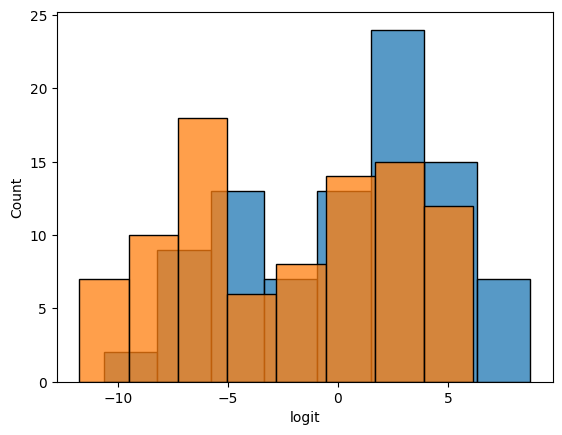

In [7]:
import seaborn as sns
import pandas as pd
prompt, good_tokens, bad_tokens, token_list = val_data[0]
labels = [token in good_tokens for token in token_list]
res = model.query(prompt, token_list)
res_df = pd.DataFrame({'logit': res, 'label': labels})
sns.histplot(res_df[res_df['label'] == 1]['logit'])
sns.histplot(res_df[res_df['label'] == 0]['logit'])

In [8]:
print(type(train_data))
print(len(train_data))
print(train_data[0])

<class 'numpy.memmap'>
301966
5962


In [ ]:
class YourSolution():
    def classify(self, prompt, token_list):
        L = len(token_list)
        steps = 2
        beam_width=3
        decay = 0.9
        beams = [(prompt, 0.0)]
        
        logits_sum = torch.zeros((L)).to(device)
        for i in range(steps):
            candidates = []

            for beam_prompt, beam_score in beams:
                logits = torch.tensor(model.query(prompt, token_list)).to(device)
                logits_sum+=torch.softmax(logits, dim=0)# * decay**(beam_prompt.shape[0]-L)
                chosen = torch.topk(logits, beam_width)

                for idx, val in zip(chosen.indices, chosen.values):
                    next_prompt = torch.cat((beam_prompt, torch.tensor([token_list[idx]]).to(device)))
                    candidates.append((next_prompt, beam_score + val.item()))

            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:beam_width]

        logits_sorted = torch.argsort(logits_sum).tolist()
        return [token_list[i] for i in logits_sorted[:L // 2]], [token_list[i] for i in logits_sorted[L // 2:]]

# Evaluation

Running the cell below will allow you to check how many points your solution would score on the validation data. Before submitting, ensure that the entire notebook runs from start to finish without errors and without requiring user intervention after selecting the "Run All" option.

In [ ]:

if not FINAL_EVALUATION_MODE:
    your_solution = YourSolution()
    print(f"Score for YourSolution: {evaluate_solution(your_solution, val_data)} pts")

  0%|          | 0/99 [00:00<?, ?it/s]


Final result:
  Processed:          99 examples
  Mean accuracy:       0.6109
  Points:             0 / 100
Score for YourSolution: 0 pts
